In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

vocab = [
    "Inventory", "Order", "Cabinet", "Drug", "Invoice",
    "Shipment", "Receive", "Restock", "Forecast", "Scenario",
]
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for i, w in enumerate(vocab)}
vocab_size = len(vocab)

def one_hot(word):
    v = np.zeros(vocab_size)
    v[word_to_id[word]] = 1.0
    return v

def cosine(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-9
    return float(a @ b) / denom

r  = one_hot("Receive")
rs = one_hot("Restock")
sc = one_hot("Scenario")

print("Receive  one-hot:", r.astype(int))
print("Restock  one-hot:", rs.astype(int))
print("Scenario one-hot:", sc.astype(int))
print()
print(f"cosine(Receive, Restock)  = {cosine(r, rs):.2f}")
print(f"cosine(Receive, Scenario) = {cosine(r, sc):.2f}")
print("\nEvery distinct one-hot pair scores 0.0 — one-hot encoding says all words are equally unrelated.")

Receive  one-hot: [0 0 0 0 0 0 1 0 0 0]
Restock  one-hot: [0 0 0 0 0 0 0 1 0 0]
Scenario one-hot: [0 0 0 0 0 0 0 0 0 1]

cosine(Receive, Restock)  = 0.00
cosine(Receive, Scenario) = 0.00

Every distinct one-hot pair scores 0.0 — one-hot encoding says all words are equally unrelated.


In [ ]:
pairs = [
    ("Order",     "Shipment"),
    ("Shipment",  "Receive"),
    ("Receive",   "Restock"),
    ("Restock",   "Inventory"),
    ("Inventory", "Forecast"),
    ("Forecast",  "Order"),
]
X = np.array([word_to_id[a] for a, _ in pairs])
Y = np.array([word_to_id[b] for _, b in pairs])

embed_dim  = 4
hidden_dim = 16

Embedding = np.random.randn(vocab_size, embed_dim) * 0.5
W1 = np.random.randn(embed_dim, hidden_dim) * 0.5
b1 = np.zeros(hidden_dim)
W2 = np.random.randn(hidden_dim, vocab_size) * 0.5
b2 = np.zeros(vocab_size)

print("Embedding matrix shape (V x E):", Embedding.shape)
print("Before training, 'Receive' embedding is just random noise:")
print("  Receive :", np.round(Embedding[word_to_id['Receive']], 2))
print("  Restock :", np.round(Embedding[word_to_id['Restock']], 2))

Embedding matrix shape (V x E): (10, 4)
Before training, 'Receive' embedding is just random noise:
  Receive : [-0.27  0.06 -0.58  0.19]
  Restock : [-0.3  -0.15 -0.3   0.93]


In [ ]:
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def forward(x_ids, params):
    Emb, W1, b1, W2, b2 = params
    emb = Emb[x_ids]
    a1  = np.tanh(emb @ W1 + b1)
    probs = softmax(a1 @ W2 + b2)
    return probs, (x_ids, emb, a1)

def cross_entropy(probs, y_ids):
    n = len(y_ids)
    return -np.mean(np.log(probs[np.arange(n), y_ids] + 1e-9))

def train(params, X, Y, epochs=3000, lr=0.5, log=True):
    Emb, W1, b1, W2, b2 = params
    for epoch in range(1, epochs + 1):
        probs, (x_ids, emb, a1) = forward(X, (Emb, W1, b1, W2, b2))
        n = len(Y)
        dz2 = probs.copy(); dz2[np.arange(n), Y] -= 1; dz2 /= n
        dW2 = a1.T @ dz2;  db2 = dz2.sum(0)
        dz1 = (dz2 @ W2.T) * (1 - a1**2)
        dW1 = emb.T @ dz1; db1 = dz1.sum(0)
        demb = dz1 @ W1.T
        dEmb = np.zeros_like(Emb)
        np.add.at(dEmb, x_ids, demb)
        Emb -= lr*dEmb; W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2
        if log and (epoch % 500 == 0 or epoch == 1):
            acc = np.mean(probs.argmax(1) == Y)
            print(f"epoch {epoch:4d} | loss {cross_entropy(probs, Y):.4f} | acc {acc:.0%}")
    return (Emb, W1, b1, W2, b2)

params = (Embedding, W1, b1, W2, b2)
params = train(params, X, Y, epochs=3000, lr=0.5)
Embedding, W1, b1, W2, b2 = params
print("\nTraining complete — the embedding rows are now meaningful, not random.")

epoch    1 | loss 2.8817 | acc 17%
epoch  500 | loss 0.0017 | acc 100%
epoch 1000 | loss 0.0008 | acc 100%
epoch 1500 | loss 0.0006 | acc 100%
epoch 2000 | loss 0.0004 | acc 100%
epoch 2500 | loss 0.0003 | acc 100%
epoch 3000 | loss 0.0003 | acc 100%

Training complete — the embedding rows are now meaningful, not random.


In [ ]:
header = "Word".ljust(11) + "".join(f"  feat{j}".rjust(9) for j in range(embed_dim))
print(header)
print("-" * len(header))
for i, w in enumerate(vocab):
    row = "".join(f"{v:9.2f}" for v in Embedding[i])
    print(w.ljust(11) + row)

Word           feat0    feat1    feat2    feat3
-----------------------------------------------
Inventory       0.23     0.00     0.86     1.86
Order           0.35    -1.31     1.44    -0.55
Cabinet        -0.23     0.27    -0.23    -0.23
Drug            0.12    -0.96    -0.86    -0.28
Invoice        -0.51     0.16    -0.45    -0.71
Shipment        1.29     1.11     0.29    -0.82
Receive        -1.17     1.39    -0.17     0.57
Restock        -0.38    -1.11    -1.24     1.27
Forecast       -0.45    -0.43    -0.85    -1.62
Scenario        0.10    -0.98    -0.66     0.10


In [ ]:
def emb(word):
    return Embedding[word_to_id[word]]

def similarity(w1, w2):
    return cosine(emb(w1), emb(w2))

print("The Week 2 question, answered with learned embeddings:")
print(f"  cosine(Receive, Restock)  = {similarity('Receive', 'Restock'):+.2f}")
print(f"  cosine(Receive, Scenario) = {similarity('Receive', 'Scenario'):+.2f}")
print()

scores = [(w, similarity('Receive', w)) for w in vocab if w != 'Receive']
scores.sort(key=lambda t: t[1], reverse=True)
print("Words most similar to 'Receive' (by cosine):")
for w, s in scores:
    print(f"  {w:10s} {s:+.2f}")

The Week 2 question, answered with learned embeddings:
  cosine(Receive, Restock)  = -0.04
  cosine(Receive, Scenario) = -0.58

Words most similar to 'Receive' (by cosine):
  Cabinet    +0.60
  Invoice    +0.26
  Inventory  +0.16
  Restock    -0.04
  Shipment   -0.13
  Forecast   -0.23
  Scenario   -0.58
  Drug       -0.59
  Order      -0.71


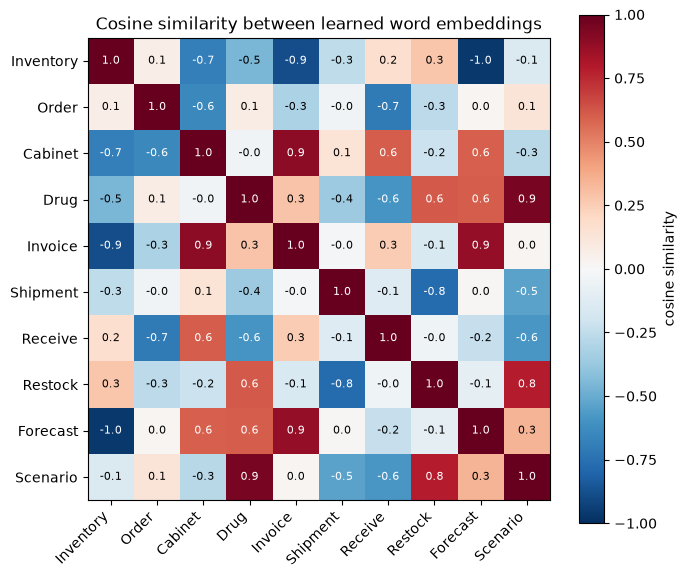

In [ ]:
def similarity_matrix(matrix, labels):
    n = len(labels)
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            M[i, j] = cosine(matrix[i], matrix[j])
    return M

S = similarity_matrix(Embedding, vocab)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(vocab_size)); ax.set_xticklabels(vocab, rotation=45, ha="right")
ax.set_yticks(range(vocab_size)); ax.set_yticklabels(vocab)
for i in range(vocab_size):
    for j in range(vocab_size):
        ax.text(j, i, f"{S[i,j]:.1f}", ha="center", va="center",
                color="white" if abs(S[i,j]) > 0.5 else "black", fontsize=8)
ax.set_title("Cosine similarity between learned word embeddings")
fig.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.show()